# Pokec-z Fairness GNN Experiments

Node classification on Pokec-z with fairness analysis (resampling + FairGNN),
GNNExplainer interpretability, and robustness evaluation.

**Methods compared:**
- Baseline: GraphSAGE
- Pre-processing: Oversampled GraphSAGE
- In-training: FairGNN (adversarial debiasing)

**Sensitive attribute:** gender (binary)

**Target:** region (binary)

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import random
import numpy as np
import torch
import yaml
import os, sys
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.join(os.getcwd(), '..'))


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/gregoirepetit/.local/share/uv/python/cpython-3.12.13-macos-x86_64-none/lib/python3.12/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/gregoirepetit/.local/share/uv/python/cpython-3.12.13-macos-x86_64-none/lib/python3.12/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/Users/gregoirepetit/Desktop/MS/P3/IADATA708-ML_fair_interpretable/project/.venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.lau

In [2]:
# Fixed seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Load config
with open('../configs/experiment.yaml') as f:
    cfg = yaml.safe_load(f)

print('Config loaded:')
print(yaml.dump(cfg, default_flow_style=False))

Config loaded:
data:
  dataset: pokec-z
  raw_dir: data/raw/pokec-z
  sensitive_cols:
  - gender
  - region
  split_ratios:
  - 0.6
  - 0.2
  - 0.2
  splits_dir: data/splits
  target_col: I_am_working_in_field
fairgnn:
  adv_hidden_dim: 64
  lambda_values:
  - 0.1
  - 0.5
  - 1.0
  - 5.0
model:
  dropout: 0.5
  epochs: 200
  hidden_dim: 256
  lr: 0.001
  num_layers: 2
  patience: 20
robustness:
  edge_drop_rates:
  - 0.1
  - 0.3
  - 0.5
  noise_levels:
  - 0.1
  - 0.3
  - 0.5
seed: 42



## 2. Data Loading & EDA

Nodes: 66,569
Edges: 729,129
Features: 264
Label balance: 0.064 (fraction occupation=1)
Gender balance: 0.487 (fraction gender=1)
Label homophily: 0.876


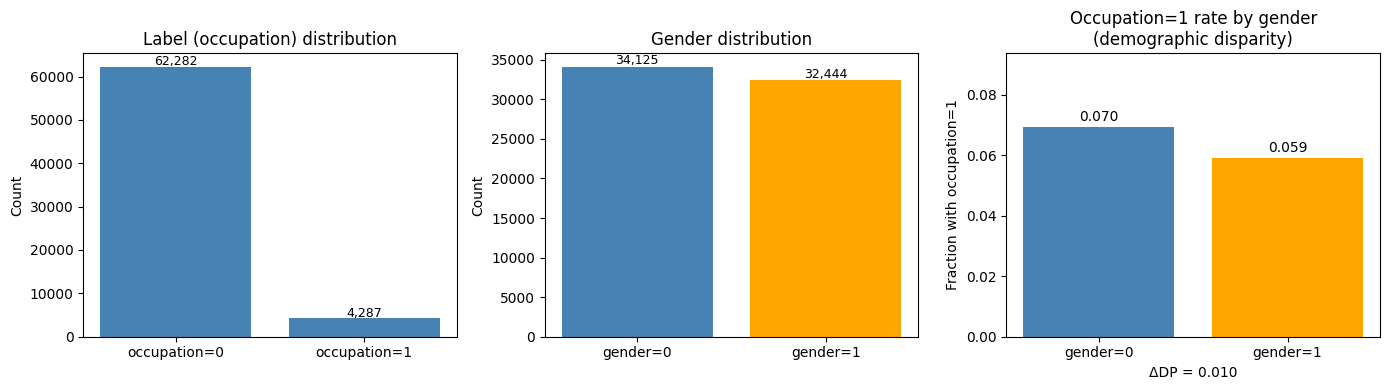

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from src.data.loader import load_pokec_z
from src.data.preprocessing import preprocess
from src.data.splits import make_splits, save_splits

RAW_DIR = cfg['data']['raw_dir']
DATA_AVAILABLE = os.path.exists(os.path.join('..', RAW_DIR, 'region_job_2.csv'))

if DATA_AVAILABLE:
    data = load_pokec_z(os.path.join('..', RAW_DIR))
    data = preprocess(data, sensitive_cols=cfg['data']['sensitive_cols'])
    print(f'Nodes: {data.num_nodes:,}')
    print(f'Edges: {data.num_edges:,}')
    print(f'Features: {data.x.shape[1]}')
    print(f'Label balance: {data.y.float().mean():.3f} (fraction occupation=1)')
    print(f'Gender balance: {data.gender.float().mean():.3f} (fraction gender=1)')

    # Homophily
    src, dst = data.edge_index
    same_label = (data.y[src] == data.y[dst]).float().mean().item()
    print(f'Label homophily: {same_label:.3f}')

    # EDA plots
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    df_eda = pd.DataFrame({'occupation': data.y.tolist(), 'gender': data.gender.tolist(), 'region': data.region.tolist()})

    # Plot 1: label class imbalance
    occ_counts = df_eda['occupation'].value_counts().sort_index()
    axes[0].bar(['occupation=0', 'occupation=1'], occ_counts.values, color='steelblue')
    axes[0].set_title('Label (occupation) distribution')
    axes[0].set_ylabel('Count')
    for i, v in enumerate(occ_counts.values):
        axes[0].text(i, v + 300, f'{v:,}', ha='center', fontsize=9)

    # Plot 2: sensitive attribute balance
    g_counts = df_eda['gender'].value_counts().sort_index()
    axes[1].bar(['gender=0', 'gender=1'], g_counts.values, color=['steelblue', 'orange'])
    axes[1].set_title('Gender distribution')
    axes[1].set_ylabel('Count')
    for i, v in enumerate(g_counts.values):
        axes[1].text(i, v + 300, f'{v:,}', ha='center', fontsize=9)

    # Plot 3: occupation=1 rate per gender — quantifies the demographic disparity (ΔDP)
    occ_rate = df_eda.groupby('gender')['occupation'].mean()
    bars = axes[2].bar(['gender=0', 'gender=1'], occ_rate.values, color=['steelblue', 'orange'])
    axes[2].set_title('Occupation=1 rate by gender\n(demographic disparity)')
    axes[2].set_ylabel('Fraction with occupation=1')
    axes[2].set_ylim(0, occ_rate.max() * 1.35)
    for bar, v in zip(bars, occ_rate.values):
        axes[2].text(bar.get_x() + bar.get_width() / 2, v + 0.002, f'{v:.3f}', ha='center', fontsize=10)
    delta_dp = abs(occ_rate.values[0] - occ_rate.values[1])
    axes[2].set_xlabel(f'ΔDP = {delta_dp:.3f}')

    plt.tight_layout()
    plt.savefig('../results/figures/eda.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print('Raw data not found — skipping data loading.')
    print(f'Expected at: {RAW_DIR}')
    print('Download from: https://snap.stanford.edu/data/soc-pokec.html')


## 3. Baseline GraphSAGE

In [4]:
from src.models.graphsage import GraphSAGE
from src.models.trainer import train, evaluate
from src.fairness.metrics import compute_all_fairness_metrics, sensitive_leakage
import torch.nn.functional as F

def to_numpy(tensor):
    """Convert a tensor to a numpy array on any device/build."""
    return np.array(tensor.detach().cpu().tolist(), dtype=np.float32)

SEEDS = [3, 7, 21, 42, 99]
results = {}

if DATA_AVAILABLE:
    # Splits (fixed, using SEED for reproducibility of the split itself)
    train_idx, val_idx, test_idx = make_splits(
        data.num_nodes, data.y, data.gender,
        ratios=tuple(cfg['data']['split_ratios']), seed=SEED
    )
    save_splits(train_idx, val_idx, test_idx, os.path.join('..', cfg['data']['splits_dir']))

    train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    val_mask   = torch.zeros(data.num_nodes, dtype=torch.bool)
    test_mask  = torch.zeros(data.num_nodes, dtype=torch.bool)
    train_mask[train_idx] = True
    val_mask[val_idx]     = True
    test_mask[test_idx]   = True

    # --- Multi-seed baseline ---
    seed_records = []
    for seed in SEEDS:
        torch.manual_seed(seed)
        model_s = GraphSAGE(
            in_channels=data.x.shape[1],
            hidden_channels=cfg['model']['hidden_dim'],
            out_channels=int(data.y.max().item()) + 1,
            num_layers=cfg['model']['num_layers'],
            dropout=cfg['model']['dropout'],
        )
        train(
            model_s, data, train_mask, val_mask,
            lr=cfg['model']['lr'],
            epochs=cfg['model']['epochs'],
            patience=cfg['model']['patience'],
        )
        acc_s, f1_s = evaluate(model_s, data, test_mask)
        with torch.no_grad():
            logits_s = model_s(data.x, data.edge_index)
            pred_s = logits_s[test_mask].argmax(dim=1)
            proba_s = to_numpy(F.softmax(logits_s[test_mask], dim=1))
            emb_s = model_s.get_embeddings(data.x, data.edge_index)
        fairness_s = compute_all_fairness_metrics(
            pred_s, data.y[test_mask], data.gender[test_mask], proba=proba_s
        )
        leakage_s = sensitive_leakage(emb_s, data.gender, seed=seed)
        seed_records.append({'acc': acc_s, 'f1': f1_s, 'leakage': leakage_s, **fairness_s})
        print(f'  seed={seed} Acc={acc_s:.4f} F1={f1_s:.4f} ΔDP={fairness_s["delta_dp"]:.4f} leakage={leakage_s:.4f}')

    # Aggregate multi-seed stats
    def agg(key):
        vals = [r[key] for r in seed_records]
        return float(np.mean(vals)), float(np.std(vals))

    baseline = GraphSAGE(
        in_channels=data.x.shape[1],
        hidden_channels=cfg['model']['hidden_dim'],
        out_channels=int(data.y.max().item()) + 1,
        num_layers=cfg['model']['num_layers'],
        dropout=cfg['model']['dropout'],
    )
    # Re-train with fixed SEED=42 for downstream sections
    torch.manual_seed(SEED)
    train(baseline, data, train_mask, val_mask,
          lr=cfg['model']['lr'], epochs=cfg['model']['epochs'], patience=cfg['model']['patience'])
    test_acc, test_f1 = evaluate(baseline, data, test_mask)
    with torch.no_grad():
        logits = baseline(data.x, data.edge_index)
        pred = logits[test_mask].argmax(dim=1)
        proba = to_numpy(F.softmax(logits[test_mask], dim=1))
        emb_base = baseline.get_embeddings(data.x, data.edge_index)
    fairness = compute_all_fairness_metrics(pred, data.y[test_mask], data.gender[test_mask], proba=proba)
    leakage_base = sensitive_leakage(emb_base, data.gender, seed=SEED)

    acc_mean, acc_std = agg('acc')
    f1_mean,  f1_std  = agg('f1')
    dp_mean,  dp_std  = agg('delta_dp')
    lk_mean,  lk_std  = agg('leakage')

    results['baseline'] = {
        'acc': test_acc, 'f1': test_f1,
        'acc_mean': acc_mean, 'acc_std': acc_std,
        'f1_mean': f1_mean, 'f1_std': f1_std,
        'dp_mean': dp_mean, 'dp_std': dp_std,
        'lk_mean': lk_mean, 'lk_std': lk_std,
        'leakage': leakage_base,
        **fairness,
    }
    print(f'\nBaseline (seed=42) Acc={test_acc:.4f} F1={test_f1:.4f} ΔDP={fairness["delta_dp"]:.4f} leakage={leakage_base:.4f}')
    print(f'Multi-seed ({len(SEEDS)} seeds): Acc={acc_mean:.4f}±{acc_std:.4f} F1={f1_mean:.4f}±{f1_std:.4f} ΔDP={dp_mean:.4f}±{dp_std:.4f} leakage={lk_mean:.4f}±{lk_std:.4f}')
else:
    print('Skipping — data not available.')


RuntimeError: Numpy is not available

## 4. Pre-processing: Resampling

In [ ]:
from src.fairness.resampling import oversample_train_mask

if DATA_AVAILABLE:
    oversampled_idx = oversample_train_mask(train_mask, data.y, data.gender, seed=SEED)
    print(f'Original train size: {train_mask.sum().item():,}')
    print(f'Oversampled train size: {len(oversampled_idx):,}')

    torch.manual_seed(SEED)
    resample_model = GraphSAGE(
        in_channels=data.x.shape[1],
        hidden_channels=cfg['model']['hidden_dim'],
        out_channels=int(data.y.max().item()) + 1,
        num_layers=cfg['model']['num_layers'],
        dropout=cfg['model']['dropout'],
    )

    # Convert oversampled index tensor to bool mask (may have repeated indices)
    os_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    os_mask[oversampled_idx] = True

    best_val_f1_rs, history_rs = train(
        resample_model, data, os_mask, val_mask,
        lr=cfg['model']['lr'],
        epochs=cfg['model']['epochs'],
        patience=cfg['model']['patience'],
    )

    test_acc_rs, test_f1_rs = evaluate(resample_model, data, test_mask)

    with torch.no_grad():
        logits_rs = resample_model(data.x, data.edge_index)
        pred_rs = logits_rs[test_mask].argmax(dim=1)
        proba_rs = to_numpy(F.softmax(logits_rs[test_mask], dim=1))

    fairness_rs = compute_all_fairness_metrics(
        pred_rs, data.y[test_mask], data.gender[test_mask], proba=proba_rs
    )

    results['resampling'] = {'acc': test_acc_rs, 'f1': test_f1_rs, **fairness_rs}
    print(f'Resampling — Acc: {test_acc_rs:.4f} | F1: {test_f1_rs:.4f} | ΔDP: {fairness_rs["delta_dp"]:.4f} | ΔEO: {fairness_rs["delta_eo"]:.4f}')
else:
    print('Skipping — data not available.')


## 5. FairGNN λ Grid Search

In [ ]:
from src.models.fairgnn import FairGNN, fairgnn_loss

fairgnn_results = {}

if DATA_AVAILABLE:
    for lam in cfg['fairgnn']['lambda_values']:
        torch.manual_seed(SEED)
        model_fg = FairGNN(
            in_channels=data.x.shape[1],
            hidden_channels=cfg['model']['hidden_dim'],
            out_channels=int(data.y.max().item()) + 1,
            adv_hidden=cfg['fairgnn']['adv_hidden_dim'],
            num_layers=cfg['model']['num_layers'],
            dropout=cfg['model']['dropout'],
        )
        optimizer_fg = torch.optim.Adam(model_fg.parameters(), lr=cfg['model']['lr'], weight_decay=5e-4)

        best_val_f1_fg = 0.0
        best_state_fg = None
        patience_counter = 0

        for epoch in range(cfg['model']['epochs']):
            model_fg.train()
            optimizer_fg.zero_grad()
            pred_logits, adv_logits = model_fg(data.x, data.edge_index)
            loss = fairgnn_loss(pred_logits, adv_logits, data.y, data.gender, train_mask, lam)
            loss.backward()
            optimizer_fg.step()

            model_fg.eval()
            with torch.no_grad():
                pl, _ = model_fg(data.x, data.edge_index)
                val_pred = pl[val_mask].argmax(dim=1)
                from sklearn.metrics import f1_score
                val_f1 = f1_score(data.y[val_mask].tolist(), val_pred.tolist(), average='macro', zero_division=0)

            if val_f1 > best_val_f1_fg:
                best_val_f1_fg = val_f1
                best_state_fg = {k: v.clone() for k, v in model_fg.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= cfg['model']['patience']:
                    break

        model_fg.load_state_dict(best_state_fg)
        model_fg.eval()
        with torch.no_grad():
            pl_test, _ = model_fg(data.x, data.edge_index)
            pred_fg = pl_test[test_mask].argmax(dim=1)
            proba_fg = to_numpy(F.softmax(pl_test[test_mask], dim=1))

        from sklearn.metrics import accuracy_score
        acc_fg = accuracy_score(data.y[test_mask].tolist(), pred_fg.tolist())
        f1_fg = f1_score(data.y[test_mask].tolist(), pred_fg.tolist(), average='macro', zero_division=0)
        fair_fg = compute_all_fairness_metrics(
            pred_fg, data.y[test_mask], data.gender[test_mask], proba=proba_fg
        )
        fairgnn_results[lam] = {'acc': acc_fg, 'f1': f1_fg, **fair_fg}
        print(f'FairGNN λ={lam} — Acc: {acc_fg:.4f} | F1: {f1_fg:.4f} | ΔDP: {fair_fg["delta_dp"]:.4f} | ΔEO: {fair_fg["delta_eo"]:.4f}')

    # Best lambda: minimize ΔDP while keeping F1 close to baseline
    best_lam = min(fairgnn_results, key=lambda l: fairgnn_results[l]['delta_dp'])
    results['fairgnn'] = fairgnn_results[best_lam]
    print(f'\nBest λ={best_lam} (lowest ΔDP)')
else:
    print('Skipping — data not available.')


## 6. GNNExplainer Analysis

In [ ]:
from src.interpretability.explainer import explain_group

if DATA_AVAILABLE:
    test_nodes = test_idx.tolist()

    # 5 nodes per gender group
    g0_nodes = [n for n in test_nodes if data.gender[n].item() == 0][:5]
    g1_nodes = [n for n in test_nodes if data.gender[n].item() == 1][:5]

    print('Explaining gender=0 group...')
    exp_g0 = explain_group(baseline, data, g0_nodes)

    print('Explaining gender=1 group...')
    exp_g1 = explain_group(baseline, data, g1_nodes)

    # Plot feature importance comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    feat_names = data.feature_cols if hasattr(data, 'feature_cols') else [f'f{i}' for i in range(data.x.shape[1])]

    fi_g0 = exp_g0['mean_feat_importance'].detach().cpu().numpy()
    fi_g1 = exp_g1['mean_feat_importance'].detach().cpu().numpy()

    top_k = min(15, len(feat_names))
    top_idx = np.argsort(fi_g0 + fi_g1)[-top_k:][::-1]

    axes[0].barh([feat_names[i] for i in top_idx], fi_g0[top_idx])
    axes[0].set_title('Feature importance — gender=0')
    axes[1].barh([feat_names[i] for i in top_idx], fi_g1[top_idx])
    axes[1].set_title('Feature importance — gender=1')
    plt.tight_layout()
    plt.savefig('../results/figures/feature_importance.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print('Skipping — data not available.')

## 7. Robustness Experiments

In [ ]:
from src.robustness.perturbations import add_feature_noise, drop_edges
from torch_geometric.data import Data as PyGData

robustness_results = {'noise': {}, 'edge_drop': {}}

if DATA_AVAILABLE:
    # Feature noise
    for sigma in cfg['robustness']['noise_levels']:
        x_noisy = add_feature_noise(data.x, sigma=sigma, seed=SEED)
        noisy_data = PyGData(x=x_noisy, edge_index=data.edge_index, y=data.y)
        noisy_data.gender = data.gender
        acc_n, f1_n = evaluate(baseline, noisy_data, test_mask)
        robustness_results['noise'][sigma] = {'acc': acc_n, 'f1': f1_n}
        print(f'Noise σ={sigma} — Acc: {acc_n:.4f} | F1: {f1_n:.4f}')

    # Edge drop
    for rate in cfg['robustness']['edge_drop_rates']:
        ei_dropped = drop_edges(data.edge_index, rate=rate, seed=SEED)
        dropped_data = PyGData(x=data.x, edge_index=ei_dropped, y=data.y)
        dropped_data.gender = data.gender
        acc_d, f1_d = evaluate(baseline, dropped_data, test_mask)
        robustness_results['edge_drop'][rate] = {'acc': acc_d, 'f1': f1_d}
        print(f'Edge drop rate={rate} — Acc: {acc_d:.4f} | F1: {f1_d:.4f}')

    # Robustness curves
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sigmas = list(robustness_results['noise'].keys())
    f1_noise = [robustness_results['noise'][s]['f1'] for s in sigmas]
    axes[0].plot([0] + sigmas, [results.get('baseline', {}).get('f1', 0)] + f1_noise, marker='o')
    axes[0].set_xlabel('Noise σ')
    axes[0].set_ylabel('Macro F1')
    axes[0].set_title('Robustness to feature noise')

    rates = list(robustness_results['edge_drop'].keys())
    f1_drop = [robustness_results['edge_drop'][r]['f1'] for r in rates]
    axes[1].plot([0] + rates, [results.get('baseline', {}).get('f1', 0)] + f1_drop, marker='o')
    axes[1].set_xlabel('Edge drop rate')
    axes[1].set_ylabel('Macro F1')
    axes[1].set_title('Robustness to edge drop')
    plt.tight_layout()
    plt.savefig('../results/figures/robustness_curves.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print('Skipping — data not available.')

## 8. Synthesis

In [ ]:
if DATA_AVAILABLE and results:
    import numpy as np

    # Summary table with multi-seed stats where available
    rows = []
    for method, r in results.items():
        acc_str = f"{r.get('acc_mean', r['acc']):.4f}±{r.get('acc_std', 0):.4f}" if 'acc_mean' in r else f"{r['acc']:.4f}"
        f1_str  = f"{r.get('f1_mean', r['f1']):.4f}±{r.get('f1_std', 0):.4f}"   if 'f1_mean'  in r else f"{r['f1']:.4f}"
        dp_str  = f"{r.get('dp_mean', r.get('delta_dp', float('nan'))):.4f}±{r.get('dp_std', 0):.4f}" if 'dp_mean' in r else f"{r.get('delta_dp', float('nan')):.4f}"
        lk_str  = f"{r.get('lk_mean', r.get('leakage', float('nan'))):.4f}±{r.get('lk_std', 0):.4f}" if 'lk_mean' in r else f"{r.get('leakage', float('nan')):.4f}"
        rows.append({
            'Method':    method,
            'Accuracy':  acc_str,
            'Macro F1':  f1_str,
            'ΔDP':       dp_str,
            'ΔEO':       f"{r.get('delta_eo', float('nan')):.4f}",
            'AUC gap':   f"{r.get('group_auc_gap', float('nan')):.4f}",
            'Leakage':   lk_str,
        })

    summary_df = pd.DataFrame(rows)
    print('\n=== Results Summary ===')
    print(summary_df.to_string(index=False))

    # Pareto curve: accuracy vs ΔDP
    fig, ax = plt.subplots(figsize=(7, 5))
    colors = {'baseline': 'steelblue', 'resampling': 'orange', 'fairgnn': 'green'}
    for method, r in results.items():
        dp = r.get('dp_mean', r.get('delta_dp', 0))
        f1 = r.get('f1_mean', r.get('f1', 0))
        dp_err = r.get('dp_std', 0)
        f1_err = r.get('f1_std', 0)
        ax.errorbar(dp, f1, xerr=dp_err, yerr=f1_err,
                    fmt='o', markersize=9, label=method, color=colors.get(method, 'gray'), capsize=4, zorder=5)
        ax.annotate(method, (dp, f1), textcoords='offset points', xytext=(5, 5))

    ax.set_xlabel('ΔDP (lower = fairer)')
    ax.set_ylabel('Macro F1 (higher = better)')
    ax.set_title('Pareto front: accuracy vs fairness (mean ± std over 5 seeds)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../results/figures/pareto_fairness.png', dpi=100, bbox_inches='tight')
    plt.show()

    # Leakage bar chart
    fig2, ax2 = plt.subplots(figsize=(6, 4))
    methods = list(results.keys())
    leakages = [results[m].get('lk_mean', results[m].get('leakage', 0)) for m in methods]
    leakage_errs = [results[m].get('lk_std', 0) for m in methods]
    ax2.bar(methods, leakages, yerr=leakage_errs, capsize=5,
            color=[colors.get(m, 'gray') for m in methods], alpha=0.8)
    ax2.axhline(0.5, color='red', linestyle='--', label='Majority baseline')
    ax2.set_ylabel('Sensitive attribute leakage (accuracy)')
    ax2.set_title('Sensitive attribute leakage by method')
    ax2.legend()
    plt.tight_layout()
    plt.savefig('../results/figures/leakage_comparison.png', dpi=100, bbox_inches='tight')
    plt.show()

    # Save metrics to CSV
    os.makedirs('../results/metrics', exist_ok=True)
    summary_df.to_csv('../results/metrics/results_summary.csv', index=False)
    print('\nSaved to results/metrics/results_summary.csv')
else:
    print('No results to display — run with data available.')
